Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Exercise03

## Problem

In the last exercise, you used tabular analyses to examine how eviction impacts tenants in Montgomery and Prince George's Counties. In this exercise, you will use more precise, address-level data to analyze evictions across the entire state through a spatial lens.

**You get to write your own research question, but with a few constraints:**
- It should be addressable with the provided eviction data
- It should require that you relate the eviction data to at least one other dataset, which you provide
- It should involve at least one form of spatial analysis (e.g., proximity, overlay, or measurement of another spatial relationship)

**Please write a short abstract (200-300 words) at the top of your exercise notebook that concisely summarizes your research question, how you addressed it, and the results of your analysis. Then provide reproducible code in cells below.**

### Bonus

Only a portion of the eviction records I'm providing for this exercise have addresses that can be geocoded (converting address strings to geographic coordinates) with a high degree of accuracy, or even at all. How could you assess bias in which records are accurately geocoded? (Hint: This will require you to define accuracy.) Can you write a Python script that evaluates whether higher- and lower-accuracy geocodes are randomly distributed across eviction records, or whether certain types of evictions are more or less likely to be geocoded well? **Please report your approach and findings in a separate paragraph and provide supporting code.**

## Data

[Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT)

I'm providing you with eviction warrant data for the whole state of Maryland from 2022 through December 2024. These are from the same District Court of Maryland and Department of Housing and Community Development (DHCD) [source](https://app.powerbigov.us/view?r=eyJrIjoiYWI1Yzg0YjYtNDFkZS00MDUyLThlMDctYmE1ZjY5MGI0MWJhIiwidCI6IjdkM2I4ZDAwLWY5YmUtNDZlNy05NDYwLTRlZjJkOGY3MzE0OSJ9&pageName=ReportSection) as the data from Exercise 2, but also include street addresses. While these data are technically public, it is best practice not to store address-level data on a public GitHub repository. It is also a best practice not to commit large raw data files to Git. For both these reasons, I have shared this dataset in a [Google Drive](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT) folder to which your UMD account has been invited. You should download `md_eviction_warrants_through_2024.csv` store it in the exercise03 directory on your computer before starting to code. 

There is a `.gitignore` file in the exercise03 directory that prevents any `.csv` file from being tracked by Git. As long as you don't modify this `.gitignore`, the raw data file won't get committed, pushed to your remote fork, or included in a pull request back to the course repo.

## File Management and Submitting
To submit, please:
1. Make a new branch on your fork for this exercise.
2. Make a notebook for your exercise with your first name as an underscored suffix (e.g., `exercise02_chester.ipynb`)
    - You can either copy this notebook to work off of or start with a fresh notebook. Your choice.
4. Make commits to that branch as you work on the exercise.
5. Don't commit the eviction warrant CSV or other raw data files to Git.
    - Instead, please add any other raw data files your analysis depends on the [Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT).
    - The current `.gitignore` will prevent CSV files from committing. Add additional file names/extensions as necessary.
6. Make a pull request from your branch. Ensure that the only files included in your pull request are those you intended for this exercise.

## Getting Started
To get started, here's some code I developed for geocoding the address in each eviction warrant into a geographic coordinate. You can include all or parts of this code in your own exercise, or just run this notebook to produce the `md_eviction_warrants_through_2024.geoparquet` file and import it into your own notebook to use the results.

### U.S. Census Geocoder
This geocoding process makes use of a [free geocoder provided by the US Census](https://geocoding.geo.census.gov/geocoder/). It's not the most accurate geocoder available, but it's free and fast.

### Breaking Code Into Modules
In this geocoding process, I'm demonstrating an approach to coding where you break code up into multiple modules and then import names between modules. This helps keep things tidy, allows you to easily reuse code that's generalizable between applications (e.g., the `utils.py` module here), and organize code used for more specific purposes (e.g., the `exercise03.py` and `census_geocode.py` modules).

This is exactly how packages work——modules are the basic building blocks. If you wrote an interconnected set of modules to address a certain problem space, you could publish it as a package and let others download it with conda or pip. That's how open-source software gets its start!

In [ ]:
# Research Question: Do counties with a higher black population experience more evictions? 

In [5]:
import pandas as pd
import geopandas as gpd
import utils
import exercise03
import census_geocode

%load_ext autoreload
%autoreload 2

In [6]:
# Load warrants and make sure zip codes are stored as strings without decimals
warrants_df = pd.read_csv('md_eviction_warrants_through_sept2025.csv')

# Ensure zip codes are stored as strings
warrants_df['TenantZipCode'] = warrants_df['TenantZipCode'].astype('Int64').astype('string')
warrants_df['EventDate'] = pd.to_datetime(warrants_df['EventDate'])
warrants_df['EvictedDate'] = pd.to_datetime(warrants_df['EvictedDate'])
warrants_df['SourceDate'] = pd.to_datetime(warrants_df['SourceDate'])

len(warrants_df) # How many warrants are we working with?

607881

In [10]:
# Rather than geocoding 600K+ addresses, can we get only the unique ones?
geocode_input_df = exercise03.prep_warrants_for_geocoding(warrants_df)

607881 warrants input
Reduced to 205620 unique addresses


In [11]:
# The Census Geocoder API can only accept up to 10K rows at a time, so we have to break
# our dataframe into chunks

# Split into dataframes with less than 10K rows each
geocode_input_dfs = utils.chunk_dataframe(geocode_input_df, 9999)

# Save each dataframe as a CSV without a header
utils.save_dfs_to_csv(geocode_input_dfs, 'geocode_inputs', header=False)

split dataframe into 21 chunks


In [25]:
# Geocode addresses with the Census Geocoder (set test=True to process only one file)
census_geocode.geocode_csvs('geocode_inputs', 'geocode_outputs', test=True)

TEST MODE: Processing only one file.
Saved results to: geocode_outputs\geocoderesult_df_0.csv


In [ ]:
# Recombine outputs from geocoder into a single dataframe
geocode_output_df = exercise03.combine_census_geocoded_csvs('geocode_outputs')
len(geocode_output_df)

9999

In [ ]:
# Merge geocoded address back onto the inputs with separate fields for address, city, state, and zip
geocoded_df = geocode_input_df.merge(geocode_output_df, left_index=True, right_index=True)
len(geocoded_df)

9999

In [32]:
# Use address, city, state, and zip columns to join geocodes onto original warrant records
warrants_df = warrants_df.merge(geocoded_df, on=['TenantAddress','TenantCity','TenantState','TenantZipCode'])
len(warrants_df)

50754

In [33]:
# Convert warrants into a geodataframe with points
warrants_gdf = utils.lonlat_str_to_geodataframe(warrants_df, 'match_lon_lat')

In [34]:
# What proportion of records have points?
len(warrants_gdf[warrants_gdf.lon.notnull()]) / len(warrants_gdf)

0.9524766520865351

In [35]:
# What proportion of records have exact geocode matches?
len(warrants_gdf[warrants_gdf.match_type == 'Exact']) / len(warrants_gdf)

0.5736690704180951

Parquet is a file format for tabular data that efficiently stores data of many types, including a 'geoparquet' variant that stores geometries like points, lines, and polygons. You can easily save a dataframe or geodataframe to parquet with the `.to_parquet` method. The resulting file will be much smaller and load faster than more convetional formats, such as CSV or shapefile. The downside is that you won't be able to open it with Excel, ArcGIS, or other conventional desktop software.

`pip install pyarrow`

In [ ]:
warrants_gdf.to_parquet('md_eviction_warrants_through_sept2025.geoparquet')

You can load a parquet file back to a dataframe with `pd.read_parquet('filename')` or a geoparquet back to a geodataframe with `gpd.read_parquet('filename')`

In [107]:
gdf = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [44]:
gdf

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,"1910 Fox Street APT 201, Adelphi, MD, 20783",Match,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L,-76.975276009485,39.00849469185,POINT (-76.97528 39.00849)
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,"1056-L MISTY LYNN CIRCLE, Cockeysville, MD, 21030",No_Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215",Match,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L,-76.667147580336,39.337399996263,POINT (-76.66715 39.3374)
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,"2008 KINTORE CIRCLE #103, ODENTON, MD, 21113",Match,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R,-76.7136333616,39.099213391212,POINT (-76.71363 39.09921)
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,"1035-G MISTY LYNN CIRCLE, Cockeysville, MD, 21030",Match,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46454)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50749,605703,2224.0,2023-02-06,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,13 Orion Ct,Rosedale,MD,...,"1415 EAST MADISON STREET, BALTIMORE, MD, 21205",Match,Exact,"1415 E MADISON ST, BALTIMORE, MD, 21205","-76.598484690811,39.299231090576",206420387.0,R,-76.598484690811,39.299231090576,POINT (-76.59848 39.29923)
50750,606563,1284.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,6 Marice Circle,Essex,MD,...,"5551 Force Road Unit D, Baltimore, MD, 21206",Match,Non_Exact,"5551 FORCE RD, BALTIMORE, MD, 21206","-76.536930991527,39.321920464774",206412392.0,R,-76.536930991527,39.321920464774,POINT (-76.53693 39.32192)
50751,606605,1296.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,28 Nerbay Road,Essex,MD,...,"1117 Southview Drive # 201, Oxon Hill, MD, 20745",Match,Exact,"1117 SOUTHVIEW DR, OXON HILL, MD, 20745","-76.989986667868,38.827135164414",655509317.0,R,-76.989986667868,38.827135164414,POINT (-76.98999 38.82714)
50752,606615,1229.0,2023-01-26,Warrant of Restitution - Return of Service - E...,NaN,Harford,Harford,707 Stanford Ct,Edgewood,MD,...,"6610 LAKE PARK DR UNIT 202, LAUREL, MD, 20707",No_Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY


In [ ]:
gdf.columns.tolist()

['Unnamed: 0',
 'ID',
 'EventDate',
 'EventType',
 'EventComment',
 'County',
 'Location',
 'TenantAddress',
 'TenantCity',
 'TenantState',
 'TenantZipCode',
 'CaseType',
 'CaseNumber',
 'EvictedDate',
 'Source',
 'SourceDate',
 'Year',
 'EvictionYear',
 'unique_id',
 'input_address',
 'match_status',
 'match_type',
 'match_address',
 'match_lon_lat',
 'match_tiger_line_id',
 'match_tiger_line_side',
 'lon',
 'lat',
 'geometry']

<Axes: >

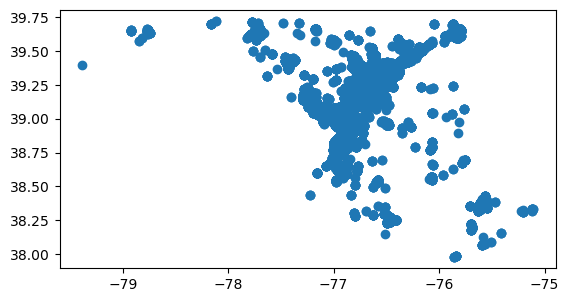

In [36]:
gdf.plot()

In [120]:
import pandas as pd
import geopandas as gpd
import requests
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Load the Maryland ACS Census Tract shapefiles.
mdtracts = gpd.read_file("tl_2025_24_tract (1)/tl_2025_24_tract.shp")

In [ ]:
#Save eviction parquet file as a geodataframe. 
evictions_gdf = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [109]:
evictions_gdf

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,"1910 Fox Street APT 201, Adelphi, MD, 20783",Match,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L,-76.975276009485,39.00849469185,POINT (-76.97528 39.00849)
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,"1056-L MISTY LYNN CIRCLE, Cockeysville, MD, 21030",No_Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215",Match,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L,-76.667147580336,39.337399996263,POINT (-76.66715 39.3374)
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,"2008 KINTORE CIRCLE #103, ODENTON, MD, 21113",Match,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R,-76.7136333616,39.099213391212,POINT (-76.71363 39.09921)
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,"1035-G MISTY LYNN CIRCLE, Cockeysville, MD, 21030",Match,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46454)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50749,605703,2224.0,2023-02-06,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,13 Orion Ct,Rosedale,MD,...,"1415 EAST MADISON STREET, BALTIMORE, MD, 21205",Match,Exact,"1415 E MADISON ST, BALTIMORE, MD, 21205","-76.598484690811,39.299231090576",206420387.0,R,-76.598484690811,39.299231090576,POINT (-76.59848 39.29923)
50750,606563,1284.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,6 Marice Circle,Essex,MD,...,"5551 Force Road Unit D, Baltimore, MD, 21206",Match,Non_Exact,"5551 FORCE RD, BALTIMORE, MD, 21206","-76.536930991527,39.321920464774",206412392.0,R,-76.536930991527,39.321920464774,POINT (-76.53693 39.32192)
50751,606605,1296.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,28 Nerbay Road,Essex,MD,...,"1117 Southview Drive # 201, Oxon Hill, MD, 20745",Match,Exact,"1117 SOUTHVIEW DR, OXON HILL, MD, 20745","-76.989986667868,38.827135164414",655509317.0,R,-76.989986667868,38.827135164414,POINT (-76.98999 38.82714)
50752,606615,1229.0,2023-01-26,Warrant of Restitution - Return of Service - E...,NaN,Harford,Harford,707 Stanford Ct,Edgewood,MD,...,"6610 LAKE PARK DR UNIT 202, LAUREL, MD, 20707",No_Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY


In [110]:
#Convert MDtracts to Eviction coordinate system.
mdtracts = mdtracts.to_crs(evictions_gdf.crs)

In [119]:
#Spatial Join the Evictions Data to the Maryland Census Tracts!
evictionsjoin = gpd.sjoin(
    evictions_gdf, mdtracts
    [["GEOID", "geometry"]],
    how = "left",
    predicate = "within"
)

In [138]:
evictionsjoin

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry,index_right,GEOID
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L,-76.975276009485,39.00849469185,POINT (-76.97528 39.00849),883.0,24033805906
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY,NaN,NaN
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L,-76.667147580336,39.337399996263,POINT (-76.66715 39.3374),410.0,24510151300
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R,-76.7136333616,39.099213391212,POINT (-76.71363 39.09921),226.0,24003740305
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46454),1279.0,24005408507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50749,605703,2224.0,2023-02-06,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,13 Orion Ct,Rosedale,MD,...,Exact,"1415 E MADISON ST, BALTIMORE, MD, 21205","-76.598484690811,39.299231090576",206420387.0,R,-76.598484690811,39.299231090576,POINT (-76.59848 39.29923),1428.0,24510100200
50750,606563,1284.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,6 Marice Circle,Essex,MD,...,Non_Exact,"5551 FORCE RD, BALTIMORE, MD, 21206","-76.536930991527,39.321920464774",206412392.0,R,-76.536930991527,39.321920464774,POINT (-76.53693 39.32192),1418.0,24510260402
50751,606605,1296.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,28 Nerbay Road,Essex,MD,...,Exact,"1117 SOUTHVIEW DR, OXON HILL, MD, 20745","-76.989986667868,38.827135164414",655509317.0,R,-76.989986667868,38.827135164414,POINT (-76.98999 38.82714),623.0,24033801704
50752,606615,1229.0,2023-01-26,Warrant of Restitution - Return of Service - E...,NaN,Harford,Harford,707 Stanford Ct,Edgewood,MD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY,NaN,NaN


In [ ]:
#Create a function for eviction rates.
def eviction_rates(evictionsjoin, geography_column):

    #Copy the dataframe.
    evictionsjoin = evictionsjoin.copy()

    #Find petitions and evictions.
    evictionsjoin["is_petition"] = evictionsjoin["EventType"] == "Petition - For Warrant of Restitution Filed"
    evictionsjoin["is_evicted"] = evictionsjoin["EventType"] == "Warrant of Restitution - Return of Service - Evicted"

    case_level = evictionsjoin.groupby(["CaseNumber", geography_column]).agg({
        "is_petition": "max",
        "is_evicted": "max"
    }).reset_index()

    case_level = case_level[case_level["is_petition"] == True]

    summary = case_level.groupby(geography_column).agg(
        total_cases = ("is_petition", "count"),
        evicted_cases = ("is_evicted", "sum")
    ).reset_index()
    summary["eviction_rate"] = (summary["evicted_cases"] / summary["total_cases"] * 100)

    return summary



<function __main__.eviction_rates(evictionsjoin, geography_column)>

In [ ]:
#Accessing ACS Data for Total Black Population at the tract level in Maryland. (Ran into a few problems with this code so Chat did help a bit!)
url = "https://api.census.gov/data/2024/acs/acs5" 
params = { 
    "get": "NAME,B02001_001E,B02001_003E", 
    "for": "tract:*",
    "in": "state:24+county:*",
    "key": "569c943d20257be865158a37195faaae77a67b2a"
    } 

response = requests.get(url, params=params) 
print(response.status_code)
print(response.text[300])

blackpop = response.json()

#Create a dataframe
bp_df = pd.DataFrame(blackpop[1:], columns=blackpop[0])
bp_df["B02001_001E"] = bp_df["B02001_001E"].astype(float)
bp_df["B02001_003E"] = bp_df["B02001_003E"].astype(float)


#Show the table
bp_df.head()


200
]


,NAME,B02001_001E,B02001_003E,state,county,tract
0,Census Tract 1; Allegany County; Maryland,3334.0,10.0,24,001,000100
1,Census Tract 2; Allegany County; Maryland,4030.0,700.0,24,001,000200
2,Census Tract 5; Allegany County; Maryland,2108.0,229.0,24,001,000500
3,Census Tract 6; Allegany County; Maryland,2830.0,77.0,24,001,000600
4,Census Tract 7; Allegany County; Maryland,3293.0,70.0,24,001,000700


In [ ]:
#Rename columns for readability.
bp_df = bp_df.rename(columns={'B02001_001E': 'Total Population', 'B02001_003E': 'Black Population'})

bp_df

,NAME,Total Population,Black Population,state,county,tract
0,Census Tract 1; Allegany County; Maryland,3334.0,10.0,24,001,000100
1,Census Tract 2; Allegany County; Maryland,4030.0,700.0,24,001,000200
2,Census Tract 5; Allegany County; Maryland,2108.0,229.0,24,001,000500
3,Census Tract 6; Allegany County; Maryland,2830.0,77.0,24,001,000600
4,Census Tract 7; Allegany County; Maryland,3293.0,70.0,24,001,000700
...,...,...,...,...,...,...
1470,Census Tract 2804.02; Baltimore city; Maryland,1299.0,1231.0,24,510,280402
1471,Census Tract 2804.03; Baltimore city; Maryland,4262.0,2410.0,24,510,280403
1472,Census Tract 2804.04; Baltimore city; Maryland,2806.0,2006.0,24,510,280404
1473,Census Tract 2805; Baltimore city; Maryland,2492.0,2283.0,24,510,280500


In [136]:
#Add a column for the percentage of African Americans within each census tract.
bp_df['Percent Black'] = ((bp_df['Black Population'] / bp_df['Total Population']) * 100).round(1)
bp_df

,NAME,Total Population,Black Population,state,county,tract,Percent Black
0,Census Tract 1; Allegany County; Maryland,3334.0,10.0,24,001,000100,0.3
1,Census Tract 2; Allegany County; Maryland,4030.0,700.0,24,001,000200,17.4
2,Census Tract 5; Allegany County; Maryland,2108.0,229.0,24,001,000500,10.9
3,Census Tract 6; Allegany County; Maryland,2830.0,77.0,24,001,000600,2.7
4,Census Tract 7; Allegany County; Maryland,3293.0,70.0,24,001,000700,2.1
...,...,...,...,...,...,...,...
1470,Census Tract 2804.02; Baltimore city; Maryland,1299.0,1231.0,24,510,280402,94.8
1471,Census Tract 2804.03; Baltimore city; Maryland,4262.0,2410.0,24,510,280403,56.5
1472,Census Tract 2804.04; Baltimore city; Maryland,2806.0,2006.0,24,510,280404,71.5
1473,Census Tract 2805; Baltimore city; Maryland,2492.0,2283.0,24,510,280500,91.6


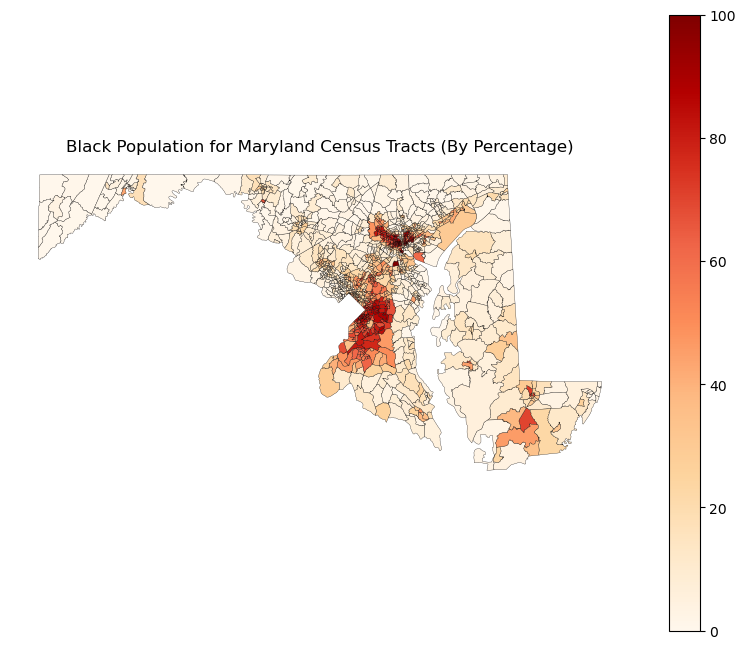

In [ ]:
#Plot the Percentage of Black Population in each Census Tract in Maryland.

#Create a GEOID for the Black Population Dataframe.
bp_df["GEOID"] = (
    bp_df["state"] + 
    bp_df["county"] + 
    bp_df["tract"])

#Ensure they are strings.
bp_df["GEOID"] = bp_df["GEOID"].astype(str)

#Merge GEOIDs for mdtracts and bp_df.
merge = mdtracts.merge(bp_df, on="GEOID")

#Plot the map.
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

merge.plot(
    column="Percent Black",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Black Population for Maryland Census Tracts (By Percentage)")
ax.axis("off")

plt.show()


In [183]:
evictionsjoin

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry,index_right,GEOID
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L,-76.975276009485,39.00849469185,POINT (-76.97528 39.00849),883.0,24033805906
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY,NaN,NaN
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L,-76.667147580336,39.337399996263,POINT (-76.66715 39.3374),410.0,24510151300
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R,-76.7136333616,39.099213391212,POINT (-76.71363 39.09921),226.0,24003740305
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46454),1279.0,24005408507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50749,605703,2224.0,2023-02-06,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,13 Orion Ct,Rosedale,MD,...,Exact,"1415 E MADISON ST, BALTIMORE, MD, 21205","-76.598484690811,39.299231090576",206420387.0,R,-76.598484690811,39.299231090576,POINT (-76.59848 39.29923),1428.0,24510100200
50750,606563,1284.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,6 Marice Circle,Essex,MD,...,Non_Exact,"5551 FORCE RD, BALTIMORE, MD, 21206","-76.536930991527,39.321920464774",206412392.0,R,-76.536930991527,39.321920464774,POINT (-76.53693 39.32192),1418.0,24510260402
50751,606605,1296.0,2023-01-27,Warrant of Restitution - Return of Service - E...,NaN,Baltimore,Essex,28 Nerbay Road,Essex,MD,...,Exact,"1117 SOUTHVIEW DR, OXON HILL, MD, 20745","-76.989986667868,38.827135164414",655509317.0,R,-76.989986667868,38.827135164414,POINT (-76.98999 38.82714),623.0,24033801704
50752,606615,1229.0,2023-01-26,Warrant of Restitution - Return of Service - E...,NaN,Harford,Harford,707 Stanford Ct,Edgewood,MD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT EMPTY,NaN,NaN


In [273]:

evictiontract_summary = eviction_rates(evictionsjoin, geography_column='GEOID')



In [274]:
print(evictiontract_summary.columns)

Index(['GEOID', 'total_cases', 'evicted_cases', 'eviction_rate'], dtype='str')


In [275]:
print(mdtracts.columns)

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='str')


In [299]:
evictionsmerge = mdtracts.merge(evictiontract_summary, on="GEOID", how="left")
evictionsmerge


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,total_cases,evicted_cases,eviction_rate
0,24,013,511000,24013511000,1400000US24013511000,5110,Census Tract 5110,G5020,S,62927091,250389,+39.5362529,-077.0856235,"POLYGON ((-77.15966 39.53446, -77.15943 39.534...",NaN,NaN,NaN
1,24,510,160600,24510160600,1400000US24510160600,1606,Census Tract 1606,G5020,S,556403,0,+39.2967497,-076.6640074,"POLYGON ((-76.66968 39.29445, -76.66961 39.294...",36.0,2.0,5.555556
2,24,510,271802,24510271802,1400000US24510271802,2718.02,Census Tract 2718.02,G5020,S,530270,0,+39.3446843,-076.6770690,"POLYGON ((-76.68345 39.34311, -76.68326 39.343...",41.0,1.0,2.439024
3,24,005,411309,24005411309,1400000US24005411309,4113.09,Census Tract 4113.09,G5020,S,9048188,5156,+39.4106874,-076.4405230,"POLYGON ((-76.46417 39.40002, -76.46411 39.400...",8.0,1.0,12.500000
4,24,005,408303,24005408303,1400000US24005408303,4083.03,Census Tract 4083.03,G5020,S,14620173,37743,+39.4688739,-076.7121070,"POLYGON ((-76.74015 39.49531, -76.74014 39.495...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470,24,005,411412,24005411412,1400000US24005411412,4114.12,Census Tract 4114.12,G5020,S,617328,0,+39.3842975,-076.5058196,"POLYGON ((-76.51227 39.38128, -76.51205 39.381...",126.0,9.0,7.142857
1471,24,005,411411,24005411411,1400000US24005411411,4114.11,Census Tract 4114.11,G5020,S,1613349,0,+39.3881772,-076.5187983,"POLYGON ((-76.53013 39.38858, -76.52926 39.389...",1.0,0.0,0.000000
1472,24,005,411413,24005411413,1400000US24005411413,4114.13,Census Tract 4114.13,G5020,S,568276,3956,+39.3926500,-076.5087827,"POLYGON ((-76.51565 39.39301, -76.51563 39.393...",NaN,NaN,NaN
1473,24,017,850600,24017850600,1400000US24017850600,8506,Census Tract 8506,G5020,S,60285430,17307,+38.5266341,-077.0933062,"POLYGON ((-77.13471 38.54101, -77.13456 38.541...",NaN,NaN,NaN


In [300]:

evictionsmerge = mdtracts.merge(
    evictiontract_summary,
    on="GEOID",
    how="left"
)

evictionsmerge["eviction_rate"] = evictionsmerge["eviction_rate"].fillna(0)

print(mdtracts.columns)
print(evictiontract_summary.columns)

evictionsmerge = gpd.GeoDataFrame(evictionsmerge, geometry="geometry")

print(len(evictionsmerge))         
print(evictionsmerge.total_bounds) 

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='str')
Index(['GEOID', 'total_cases', 'evicted_cases', 'eviction_rate'], dtype='str')
1475
[-79.4876502   37.88660425 -74.98627583  39.72303621]


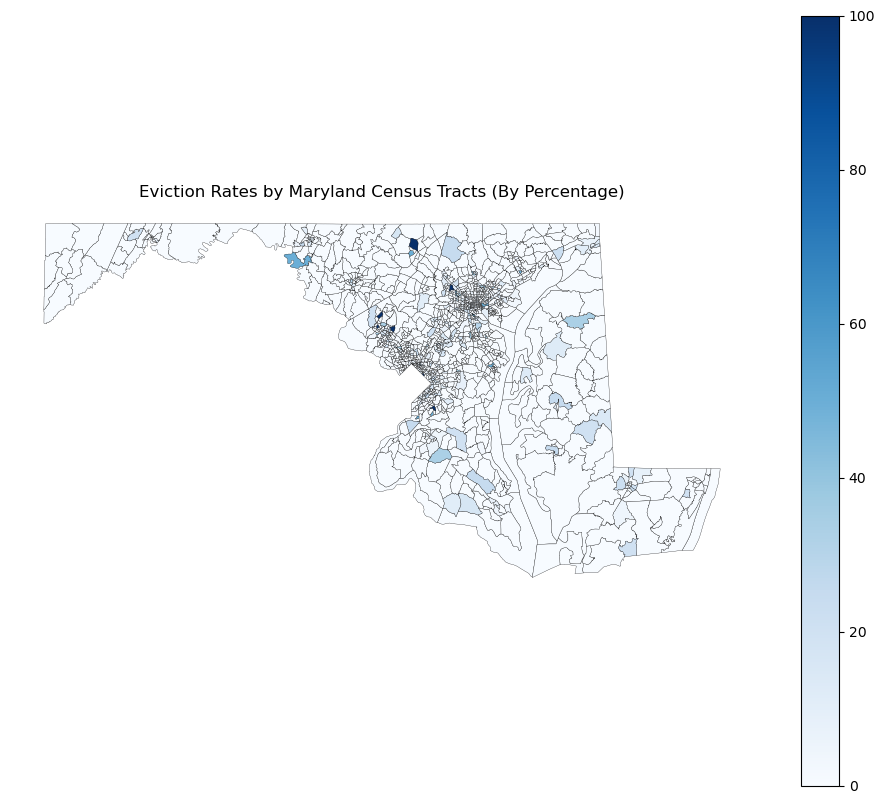

In [304]:
ax = evictionsmerge.plot(
    column="eviction_rate",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(12, 10),
)

ax.set_title("Eviction Rates by Maryland Census Tracts (By Percentage)")
ax.axis("off")

plt.show()